# Tumour Growth Simulation — Base Model and Warburg Effect

This notebook implements and compares two agent-based models of avascular solid tumour growth, based on the hybrid cellular automaton framework proposed by Gerlee & Anderson (2007).

**What we want to show:**

- **Base model:** tumour growth driven solely by oxygen availability. Each cell carries a small feed-forward neural network that maps local environmental inputs to a cellular behaviour (proliferate, quiesce, apoptose, or move). Mutations on the network weights during cell division give rise to clonal evolution and emergent morphology.
- **Warburg model:** an extension that introduces glucose consumption, H⁺ ion production, and a metabolic switch node in the neural network. Cells can switch from aerobic to glycolytic metabolism when oxygen is scarce — a hallmark of real tumours known as the Warburg effect. The glycolytic phenotype emerges spontaneously through selection pressure, not by explicit programming.

**Key concepts from complex systems:**
- Local rules → global emergent structure (layered morphology)
- Selection without explicit fitness function
- Neural network as an evolvable genotype, not a learning system
- Coupled discrete (CA) and continuous (PDE) dynamics


In [13]:
import mesa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.signal import convolve2d
import pandas as pd

---
## 1. Base Model

The base model simulates the avascular growth phase using a single chemical field (oxygen). It is a faithful simplification of the Gerlee & Anderson (2007) paper, restricted to 2 environmental inputs and 3 life-cycle outputs plus movement.

### 1.1 Environment — `TumorEnvironment`

The environment manages the spatial grid and the oxygen chemical field. It is implemented as a separate class from the Mesa model to keep chemical field logic decoupled from agent scheduling.

**Methods:**
- `__init__(width, height)` — initialises a `SingleGrid` (at most one agent per cell) and fills the oxygen field uniformly to 1.0 (normalised background concentration).
- `diffuse_resources(substeps)` — integrates the oxygen diffusion PDE using an explicit finite-difference scheme with a 5-point Laplacian kernel. To maintain numerical stability, each CA step is divided into `substeps=50` sub-iterations. The non-dimensional diffusion coefficient from the paper (D_O₂ = 1.04) is split accordingly. The Dirichlet boundary condition (oxygen = 1.0 on all borders) simulates a tissue surrounded by blood vessels.
- `supply_resources()` — enforces Dirichlet boundary conditions at the start of each CA step, before diffusion, to prevent boundary drift.
- `consume(pos, oxygen)` — subtracts the consumed oxygen at a given grid position, clamping to zero.
- `update_plot(model)` / `_save_snapshot(model, step)` — sets up and captures snapshots of the model at certain steps showing cell states and oxygen levels.


In [14]:
class TumorEnvironment:

    def __init__(self, width, height, init_oxygen=1.0):
        self.grid = mesa.space.SingleGrid(width, height, torus=False)
        self.width = width
        self.height = height
        self.oxygen = np.full((width, height), init_oxygen, dtype=np.float32)
        self.fig, self.ax = None, None
        self.im_cells, self.im_oxygen = None, None

    def diffuse_resources(self, substeps=50):
        laplacian_kernel = np.array([[0, 1, 0],
                                     [1, -4, 1],
                                     [0, 1, 0]])
        D_O2 = 1.04 / substeps
        for _ in range(substeps):
            delta = convolve2d(self.oxygen, laplacian_kernel,
                               mode='same', boundary='fill', fillvalue=1.0)
            self.oxygen += D_O2 * delta
            np.clip(self.oxygen, 0.0, None, out=self.oxygen)

    def supply_resources(self):
        self.oxygen[0, :]  = 1.0
        self.oxygen[-1, :] = 1.0
        self.oxygen[:, 0]  = 1.0
        self.oxygen[:, -1] = 1.0

    def consume(self, pos, oxygen):
        x, y = pos
        self.oxygen[x, y] = max(0.0, self.oxygen[x, y] - oxygen)  
    

    def update_plot(self, model):
        step = len(model.history)
        if not getattr(model, 'live_plot', False):
            # Save snapshot at specific steps
            if step in getattr(model, 'snapshot_steps', []):
                self._save_snapshot(model, step)
            return


    def _save_snapshot(self, model, step):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        cmap_cells = colors.ListedColormap(['white', 'red', 'green', 'black'])
        agent_matrix = np.zeros((self.width, self.height))
        for cell, (x, y) in model.grid.coord_iter():
            if cell:
                agent_matrix[x, y] = cell.state
        axes[0].imshow(agent_matrix, cmap=cmap_cells, vmin=0, vmax=3)
        axes[0].set_title(f"Cell States — step {step}")
        axes[1].imshow(self.oxygen, cmap='Greens', vmin=0, vmax=1)
        axes[1].set_title("Oxygen Levels")
        plt.tight_layout()
        plt.show()  # in Jupyter this renders inline
        plt.close()

### 1.2 Agent — `TumorCell` (base)

Each tumour cell is an individual Mesa agent carrying its own feed-forward neural network, which acts as its **genotype**. The network is not trained — it is a parametric function that maps environmental inputs to a behavioural output. Parameters mutate at each cell division, giving rise to clonal diversity and emergent selection.

**Neural network architecture:**
- **Input layer (2 nodes):** normalised neighbour count `n/8` (Moore neighbourhood, max 8) and local oxygen concentration.
- **Hidden layer (5 nodes):** sigmoid activation, weights `hidden_w`, thresholds `theta`.
- **Output layer (4 nodes):** Proliferation (P), Quiescence (Q), Apoptosis (A), Movement (MOV) — sigmoid activation, weights `output_w`, thresholds `phi`.

The life-cycle action is determined by `argmax(output[:3])`. Movement is handled independently via `output[3] > 0.5`.

**Cell states:**
| State | Meaning | Colour |
|---|---|---|
| 1 | Proliferating | Red |
| 2 | Quiescent | Green |
| 3 | Necrotic | Black |

**Methods:**
- `_sigmoid(x)` — transfer function `1 / (1 + exp(-2x))`, maps to (0, 1).
- `_mutate(w)` — applies Poisson-distributed random mutations (mean = 1% of entries) with Gaussian noise σ=0.25. This models the elevated somatic mutation rate of cancer cells.
- `proliferation(neighbors)` — places a daughter cell in a random empty neighbour, after copying and mutating the parent's network. Requires `age ≥ threshold_age` to enforce a minimum cell cycle. Both the age threshold and network weights are inherited with mutation.
- `quiescence()` — sets state to quiescent; no division, reduced oxygen consumption.
- `apoptosis()` — removes the cell from the grid (frees the space) and from the scheduler. Increments the model's apoptosis counter.
- `move(neighbors)` — relocates the cell to a random empty neighbouring position.
- `step()` — the main per-step logic: sample environment → forward pass → decide action → check necrosis → consume oxygen → execute action.

**Consumption rates (non-dimensionalised):**

| Action | O₂ rate |
|---|---|
| Proliferating | 0.025 |
| Quiescent | 0.005 |
| Apoptotic | 0.0 |

**Necrosis condition:** if local oxygen < rate × 0.3, the cell becomes necrotic. Necrotic cells remain on the grid (occupying physical space) but are removed from the scheduler.


In [15]:
class TumorCell(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.state = 1
        self.age = 0
        self.threshold_age = 10

        # Hidden layer weights: shape (5, 2) — rows = hidden nodes, cols = [n_neighbours, O2]
        self.hidden_w = np.array([
            [ 1.0,  0.0],
            [ 0.5,  0.0],
            [ 0.0, -2.0],
            [ 1.0,  0.0],
            [ 0.0,  0.0],
        ], dtype=np.float32)
        self.theta_initial = np.array([0.55, 0.0, 0.9, -0.25, 0.0], dtype=np.float32)

        # Output layer weights: shape (4, 5) — rows = [P, Q, A, MOV]
        self.output_w = np.array([
            [-0.5,  1.0, -0.5,  0.0,  0.0],
            [ 0.0,  0.55,-0.5,  0.0,  0.0],
            [ 0.0,  0.0,  4.0,  0.0,  0.0],
            [ 0.0,  0.0,  0.0,  0.0,  1.0],
        ], dtype=np.float32)
        self.phi_initial = np.array([0.0, 0.0, 0.0, 0.75], dtype=np.float32)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-2 * x))

    def _mutate(self, w):
        flat = w.flatten()
        n_mutations = np.random.poisson(0.01 * len(flat))
        if n_mutations > 0:
            indices = np.random.choice(len(flat), size=min(n_mutations, len(flat)), replace=False)
            flat[indices] += np.random.normal(0, 0.25, size=len(indices))
        return flat.reshape(w.shape)

    def proliferation(self, neighbors):
        empty_neighbors = [p for p in neighbors if self.model.grid.is_cell_empty(p)]
        if self.age < self.threshold_age:
            self.quiescence()
            return
        if not empty_neighbors:
            self.quiescence()
            return
        self.state = 1
        self.age = 0
        child = TumorCell(self.model)
        child.hidden_w      = self._mutate(self.hidden_w.copy())
        child.theta_initial = self._mutate(self.theta_initial.copy())
        child.output_w      = self._mutate(self.output_w.copy())
        child.phi_initial   = self._mutate(self.phi_initial.copy())
        child.threshold_age = max(1, int(np.random.normal(self.threshold_age,
                                                           self.threshold_age / 2)))
        self.model.grid.place_agent(child, self.random.choice(empty_neighbors))

    def quiescence(self):
        self.state = 2

    def apoptosis(self):
        self.model.apoptosis_count += 1
        self.model.grid.remove_agent(self)
        self.model.agents.discard(self)

    def move(self, neighbors):
        self.state = 2
        empty_neighbors = [p for p in neighbors if self.model.grid.is_cell_empty(p)]
        if empty_neighbors:
            self.model.env.grid.move_agent(self, self.random.choice(empty_neighbors))

    def step(self):
        self.age += 1
        O2_PROLIF, O2_QUIESC = 0.025, 0.005

        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        num_neighbors = sum(1 for n in neighbors if not self.model.grid.is_cell_empty(n))

        x, y = self.pos
        oxygen_level = self.model.env.oxygen[x, y]

        inp    = np.array([num_neighbors / 8.0, oxygen_level])
        hidden = self._sigmoid(np.dot(self.hidden_w, inp) - self.theta_initial)
        output = self._sigmoid(np.dot(self.output_w, hidden) - self.phi_initial)

        action = np.argmax(output[:3])

        rate = O2_PROLIF if action == 0 else (O2_QUIESC if action == 1 else 0.0)

        # Check for necrosis before consuming resources
        if rate > 0 and self.model.env.oxygen[x, y] < rate * 0.3:
            self.state = 3
            self.model.agents.discard(self)
            return

        if rate > 0:
            self.model.env.consume(self.pos, oxygen=rate)

        if action == 0:
            self.proliferation(neighbors)
        elif action == 1:
            self.move(neighbors) if output[3] > 0.5 else self.quiescence()
        else:
            self.apoptosis()


### 1.3 Model — `TestModel` (base)

`TestModel` sets up the whole Mesa model. It owns the environment, seeds the initial tumour cells, orchestrates the step loop and collects per-step statistics.

**Initialisation:** 4 cells placed in a 2×2 block at the grid centre. This avoids early-step artefacts from a single isolated cell.

**Step logic:**
1. Reset Dirichlet boundaries (`supply_resources`)
2. Diffuse oxygen field (`diffuse_resources`, 50 substeps)
3. Shuffle and execute all agent steps (`shuffle_do`)
4. Collect cell counts into `history`

**History keys:** `proliferating`, `quiescent`, `necrotic`, `apoptotic`, `alive`


In [16]:
class TestModelBase(mesa.Model):
    def __init__(self, width, height):
        super().__init__()
        self.env = TumorEnvironment(width, height)
        self.grid = self.env.grid
        self.history = []
        self.apoptosis_count = 0
        self.live_plot = False
        self.snapshot_steps = [1, 25, 50, 75, 100, 125, 150, 175, 200]

        cx, cy = width // 2, height // 2
        for pos in [(cx, cy), (cx+1, cy), (cx, cy+1), (cx+1, cy+1)]:
            self.grid.place_agent(TumorCell(self), pos)

    def step(self):
        self.env.supply_resources()
        self.env.diffuse_resources(substeps=50)
        self.agents.shuffle_do("step")

        counts = {'proliferating': 0, 'quiescent': 0, 'necrotic': 0}
        for agent, _ in self.grid.coord_iter():
            if agent is not None:
                if agent.state == 1:   counts['proliferating'] += 1
                elif agent.state == 2: counts['quiescent'] += 1
                elif agent.state == 3: counts['necrotic'] += 1

        counts['apoptotic'] = self.apoptosis_count
        self.apoptosis_count = 0
        counts['alive'] = counts['proliferating'] + counts['quiescent']
        self.history.append(counts)
        self.env.update_plot(self)


### 1.4 Run — Base Model

The simulation runs until 200 steps are completed. After the run, cell counts over time are plotted.


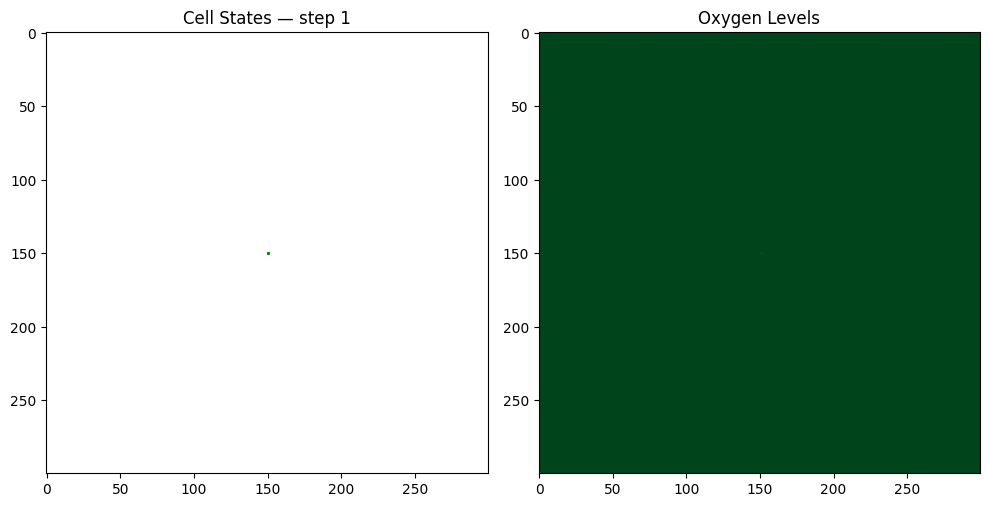

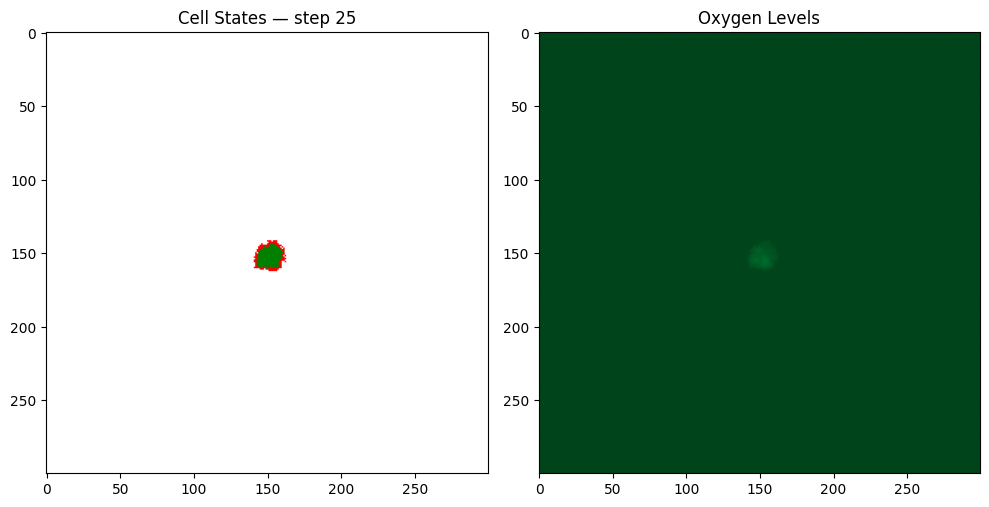

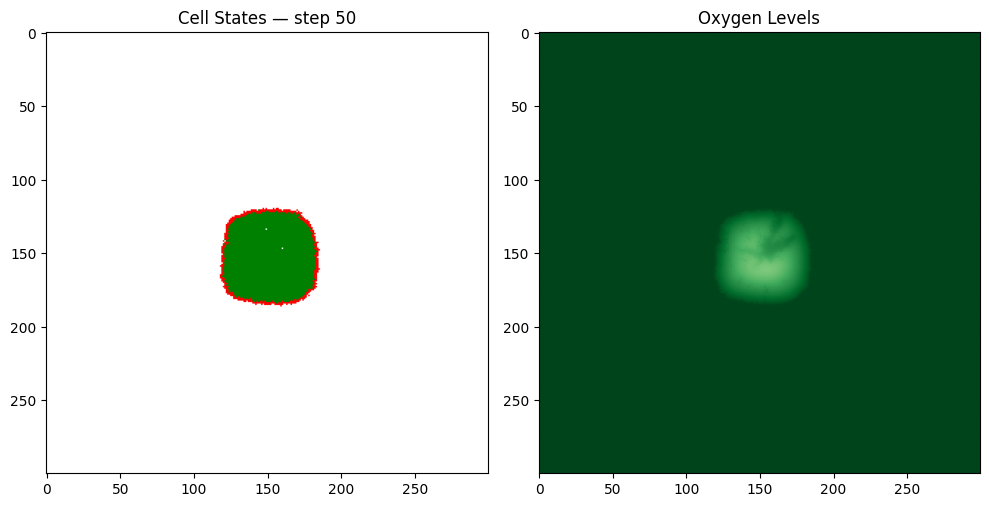

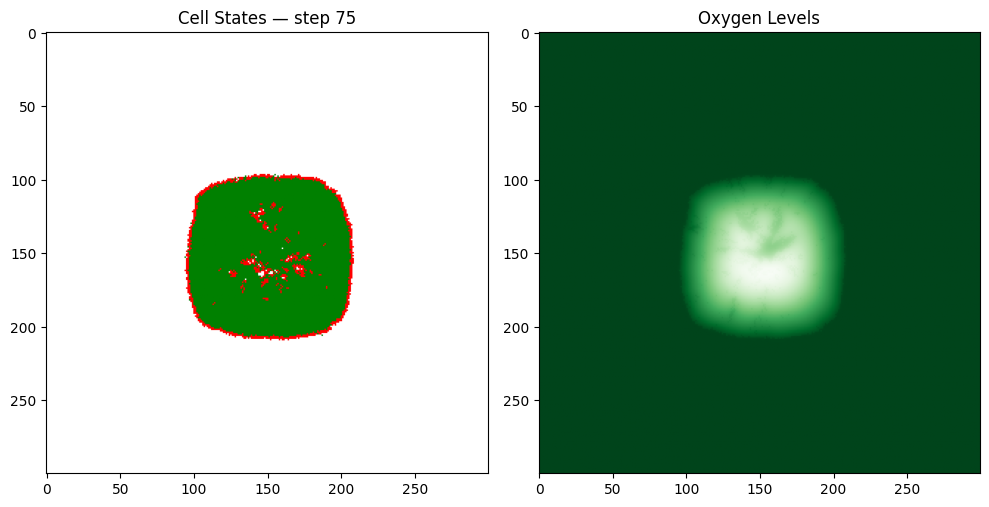

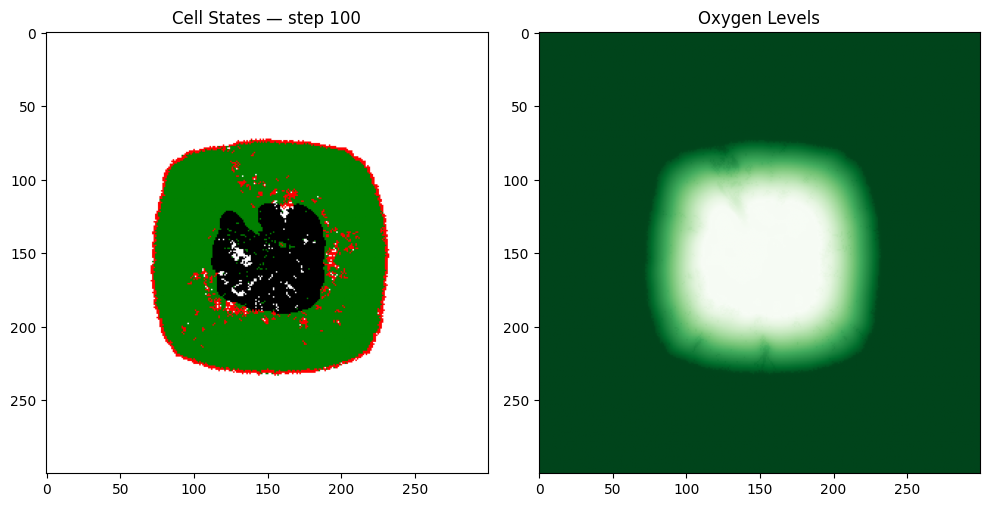

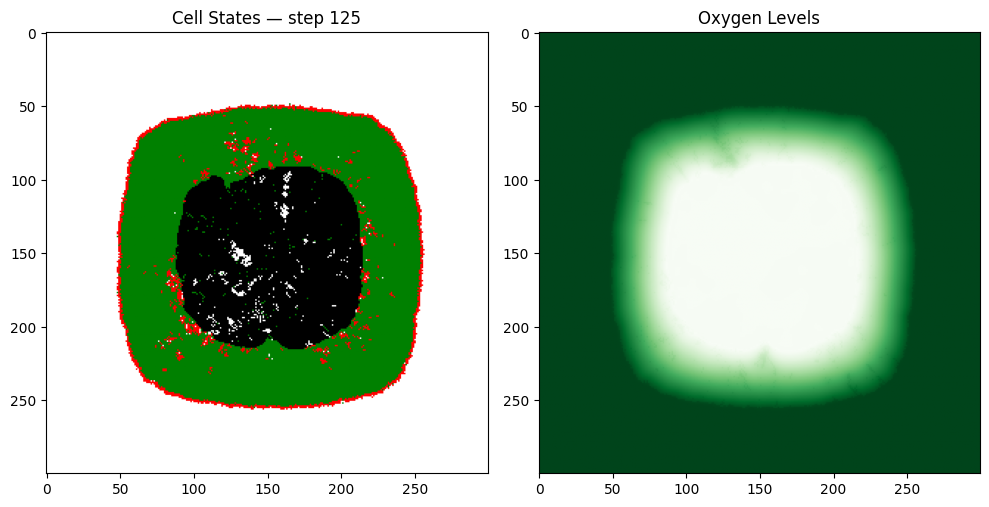

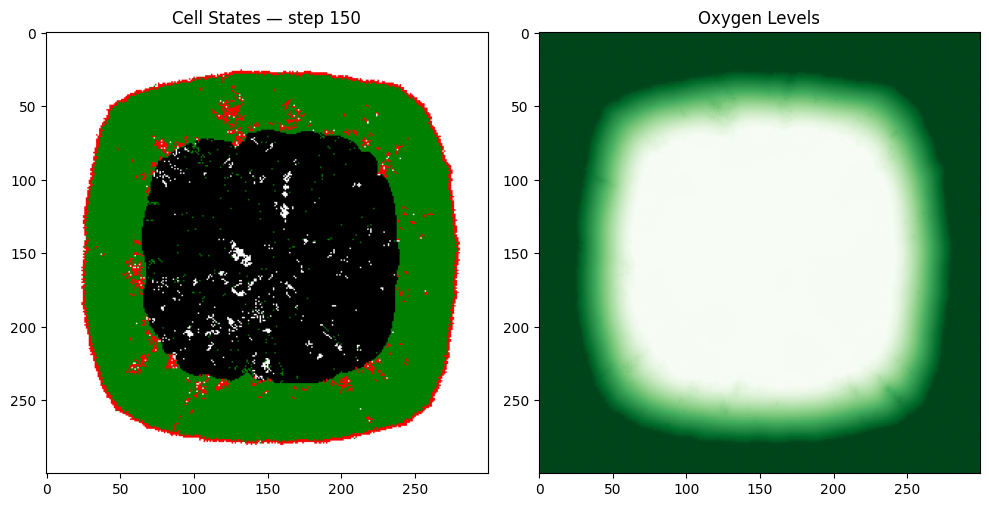

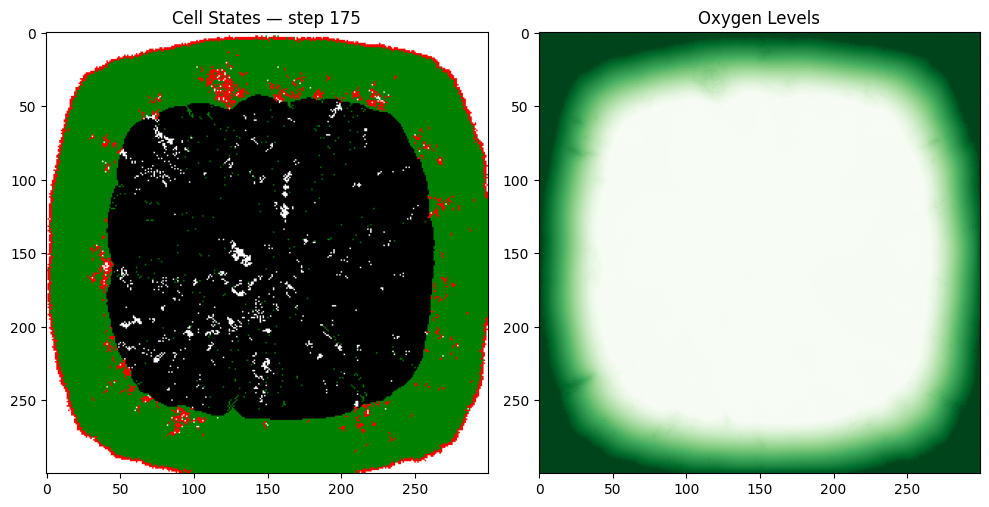

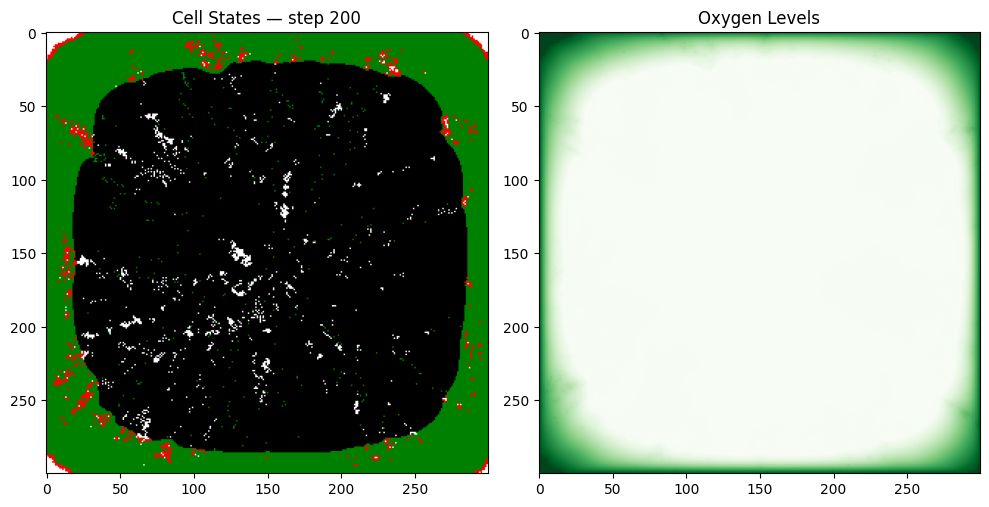

In [17]:
# ── Run base model ──────────────────────────────────────────
model_base = TestModelBase(width=300, height=300)

for i in range(200):
    print(f"Step {i+1}/200", end="\r")
    model_base.step()
  
plt.ioff()
plt.show()


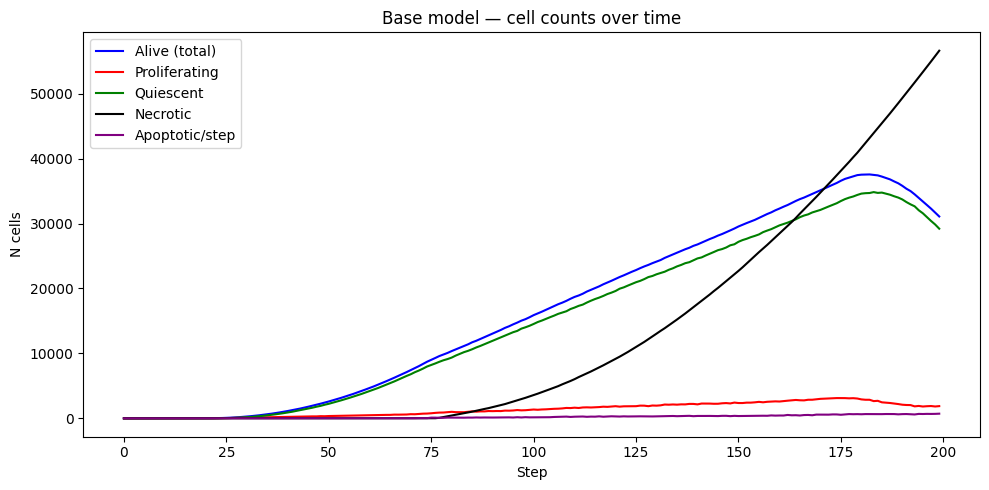

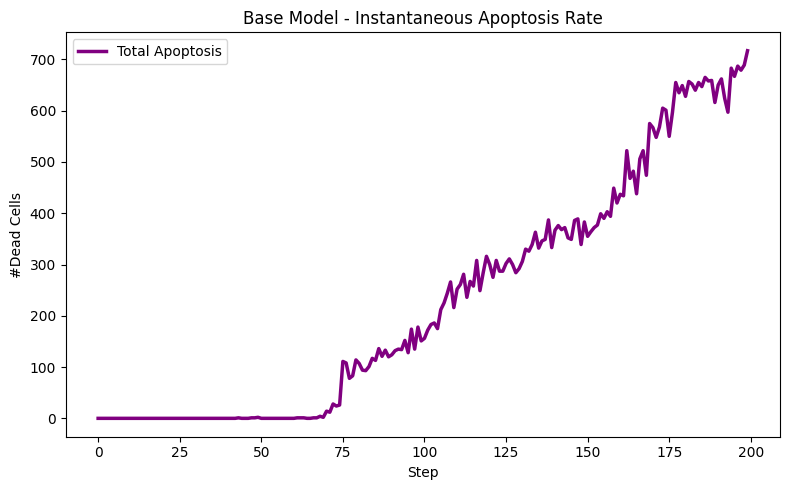

In [6]:
# ── Plot cell counts ─────────────────────────────────────────
df_base = pd.DataFrame(model_base.history)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_base['alive'],         label='Alive (total)',   color='blue')
ax.plot(df_base['proliferating'], label='Proliferating',   color='red')
ax.plot(df_base['quiescent'],     label='Quiescent',       color='green')
ax.plot(df_base['necrotic'],      label='Necrotic',        color='black')
ax.plot(df_base['apoptotic'],     label='Apoptotic/step',  color='purple')
ax.set_title("Base model — cell counts over time")
ax.set_xlabel("Step")
ax.set_ylabel("N cells")
ax.legend()
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_base['apoptotic'], color='purple', label='Total Apoptosis', linewidth=2.5)
ax.set_title("Base Model - Instantaneous Apoptosis Rate")
ax.set_xlabel("Step")
ax.set_ylabel("#Dead Cells")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Warburg Model

The Warburg model extends the base model by adding two new chemical fields (glucose and H⁺ ions) and a metabolic switch node to the neural network. This allows cells to spontaneously adopt glycolytic metabolism under hypoxic conditions — the Warburg effect.

**What changes from the base model:**
- 3 chemical fields instead of 1 (oxygen, glucose, H⁺)
- Neural network extended to 4 inputs and 5 outputs
- Hidden node H4 dedicated to sensing oxygen for the metabolic decision
- `is_glycolytic` flag per cell, determined at each step by `output[3] > 0.5`
- Distinct consumption rates for aerobic vs glycolytic cells
- 6 cell states instead of 3


### 2.1 Environment — `TumorEnvironment` (Warburg)

Three chemical fields are now maintained. The diffusion coefficients differ per field, reflecting the actual physical diffusivities from the paper (glucose diffuses ~5× faster than oxygen):

| Field | D (non-dim) | Boundary condition |
|---|---|---|
| Oxygen | 1.04 | 1.0 (constant supply) |
| Glucose | 5.24 | 1.0 (constant supply) |
| H⁺ | 0.63 | 0.0 (cleared at boundary) |

All three are updated within the same substep loop. The H⁺ field accumulates in the tumour interior as glycolytic cells produce acid; it diffuses outward and is removed at the boundaries, simulating tissue buffering by surrounding vasculature.

**New/changed methods vs base:**
- `__init__` — adds `self.glucose` and `self.h_plus` fields.
- `diffuse_resources` — applies three separate diffusion kernels with their respective coefficients.
- `supply_resources` — additionally resets glucose borders to 1.0 and H⁺ borders to 0.0.
- `consume(pos, oxygen, glucose, h_plus)` — subtracts oxygen and glucose, accumulates H⁺.
- `update_plot` / `_save_snapshot(model, step)` — sets up and saves snaps of a 2×2 subplot layout showing cell state and all three fields.


In [7]:
class TumorEnvironmentWarburg:

    def __init__(self, width, height, init_oxygen=1.0, init_glucose=1.0):
        self.grid = mesa.space.SingleGrid(width, height, torus=False)
        self.width = width
        self.height = height
        self.oxygen  = np.full((width, height), init_oxygen,  dtype=np.float32)
        self.glucose = np.full((width, height), init_glucose, dtype=np.float32)
        self.h_plus  = np.zeros((width, height), dtype=np.float32)
        self.fig, self.ax = None, None
        self.im_cells = self.im_oxygen = self.im_glucose = self.im_h_plus = None

    def diffuse_resources(self, substeps=50):
        K = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
        D_O2 = 1.04 / substeps
        D_G  = 5.24 / substeps
        D_H  = 0.63 / substeps
        for _ in range(substeps):
            self.oxygen  += D_O2 * convolve2d(self.oxygen,  K, mode='same', boundary='fill', fillvalue=1.0)
            np.clip(self.oxygen,  0.0, None, out=self.oxygen)
            self.glucose += D_G  * convolve2d(self.glucose, K, mode='same', boundary='fill', fillvalue=1.0)
            np.clip(self.glucose, 0.0, None, out=self.glucose)
            self.h_plus  += D_H  * convolve2d(self.h_plus,  K, mode='same', boundary='fill', fillvalue=0.0)
            np.clip(self.h_plus,  0.0, None, out=self.h_plus)

    def supply_resources(self):
        for field, val in [(self.oxygen, 1.0), (self.glucose, 1.0), (self.h_plus, 0.0)]:
            field[0, :] = field[-1, :] = field[:, 0] = field[:, -1] = val

    def consume(self, pos, oxygen, glucose, h_plus):
        x, y = pos
        self.oxygen[x, y]  = max(0.0, self.oxygen[x, y]  - oxygen)
        self.glucose[x, y] = max(0.0, self.glucose[x, y] - glucose)
        self.h_plus[x, y] += h_plus

    def visualize(self):
        plt.ion()
        self.fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        self.ax = axes.flatten()
        cmap_cells = colors.ListedColormap(['white', 'red', 'green', 'black', 'orange', 'blue'])
        self.im_cells   = self.ax[0].imshow(np.zeros((self.width, self.height)),
                                             cmap=cmap_cells, vmin=0, vmax=5)
        self.ax[0].set_title("Cell States")
        self.im_oxygen  = self.ax[1].imshow(self.oxygen,  cmap='Greens',  vmin=0, vmax=1)
        self.ax[1].set_title("Oxygen Levels")
        self.im_glucose = self.ax[2].imshow(self.glucose, cmap='Oranges', vmin=0, vmax=1)
        self.ax[2].set_title("Glucose Levels")
        self.im_h_plus  = self.ax[3].imshow(self.h_plus,  cmap='Blues',   vmin=0, vmax=0.1)
        self.ax[3].set_title("H⁺ Levels")
        plt.tight_layout()
    
    def update_plot(self, model):
        step = len(model.history)
        if not getattr(model, 'live_plot', False):
            # Save snapshot at specific steps
            if step in getattr(model, 'snapshot_steps', []):
                self._save_snapshot(model, step)
            return

    def _save_snapshot(self, model, step):
        fig, axes = plt.subplots(2, 2, figsize=(10, 10))
        axes = axes.flatten()
        cmap_cells = colors.ListedColormap(['white', 'red', 'green', 'black', 'orange', 'blue'])
        agent_matrix = np.zeros((self.width, self.height))
        for cell, (x, y) in model.grid.coord_iter():
            if cell:
                agent_matrix[x, y] = cell.state
        axes[0].imshow(agent_matrix, cmap=cmap_cells, vmin=0, vmax=5)
        axes[0].set_title(f"Cell States — step {step}")
        axes[1].imshow(self.oxygen, cmap='Greens', vmin=0, vmax=1)
        axes[1].set_title("Oxygen Levels")
        axes[2].imshow(self.glucose, cmap='Oranges', vmin=0, vmax=1)
        axes[2].set_title("Glucose Levels")
        axes[3].imshow(self.h_plus, cmap='Blues', vmin=0, vmax=0.1)
        axes[3].set_title("H⁺ Levels")
        
        plt.tight_layout()
        plt.show()  # in Jupyter this renders inline
        plt.close()


### 2.2 Agent — `TumorCell` (Warburg)

The Warburg agent extends the base agent with a richer neural network and metabolic logic.

**Extended neural network architecture:**
- **Input layer (4 nodes):** `[n_neighbours/8, O₂, glucose, H⁺]`
- **Hidden layer (5 nodes):** same sigmoid activation; H4 now has a dedicated connection to O₂ (weight −3.0) and H⁺ (weight −1.0), making it sensitive to the hypoxic/acid microenvironment. 
- **Output layer (5 nodes):** P, Q, A, **Metabolism (M)**, MOV

The metabolic output M determines `is_glycolytic = output[3] > 0.5`. When H4 is high (low O₂), M rises above 0.5 → glycolytic switch. The H⁺ term on H4 provides negative feedback: very high acidity lowers H4 → inhibits further glycolysis, which is biologically correct.

**Cell states:**
| State | Meaning | Colour |
|---|---|---|
| 1 | Proliferating (aerobic) | Red |
| 2 | Quiescent (aerobic) | Green |
| 3 | Necrotic | Black |
| 4 | Proliferating (glycolytic) | Orange |
| 5 | Quiescent (glycolytic) | Blue |

**Consumption rates:**

| Metabolism | Action | O₂ | Glucose | H⁺ produced |
|---|---|---|---|---|
| Aerobic | Proliferating | 0.012 | 0.003 | 0 |
| Aerobic | Quiescent | 0.002 | 0.0006 | 0 |
| Glycolytic | Proliferating | 0.0006 | 0.054 | 0.003 |
| Glycolytic | Quiescent | 0.0001 | 0.011 | 0.003 |

Glycolytic cells consume 18× more glucose than aerobic cells (stoichiometry of anaerobic glycolysis) but almost no oxygen, matching the Warburg effect. They also produce H⁺ ions, acidifying the microenvironment.

**Necrosis conditions:**
- Aerobic: O₂ < rate × 0.3
- Glycolytic: O₂ < 0.0001 or glucose < rate × 0.005 (much more tolerant to hypoxia, but dependent on glucose)

**Key design choice:** `is_glycolytic` is evaluated *before* the apoptosis check, so a glycolytic cell about to die still produces H⁺ in its final step. This correctly models the acid environment left by dying glycolytic cells.


In [18]:
class TumorCellWarburg(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.state = 1
        self.age = 0
        self.threshold_age = 10
        self.is_glycolytic = False

        # hidden_w shape (5, 4): rows = hidden nodes, cols = [n/8, O2, glucose, H+]
        self.hidden_w = np.array([
            [ 1.0,  0.0,  0.0,  0.0],
            [ 0.5,  0.0,  0.0,  0.0],
            [ 0.0, -2.0,  0.0,  0.0],
            [ 0.0,  0.0, -2.0,  0.5],
            [ 0.0, -3.0,  0.0, -1.0],  # H4: low O2 & high H+ → high H4 → glycolytic
        ], dtype=np.float32)
        self.theta_initial = np.array([0.55, 0.0, 0.9, -0.25, 0.0], dtype=np.float32)

        # output_w shape (5, 5): rows = [P, Q, A, M, MOV]
        self.output_w = np.array([
            [-0.5,  1.0, -0.5,  0.0,  0.0],
            [ 0.0,  0.55,-0.5,  0.0,  0.0],
            [ 0.0,  0.0,  2.0,  2.0,  0.0],
            [ 0.0,  0.0,  0.0,  0.0,  6.0],  # M driven by H4
            [ 0.0,  0.0,  0.0,  0.0,  1.0],
        ], dtype=np.float32)
        self.phi_initial = np.array([0.0, 0.0, 0.0, 1.5, 0.75], dtype=np.float32)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-2 * x))

    def _mutate(self, w):
        flat = w.flatten()
        n_mut = np.random.poisson(0.01 * len(flat))
        if n_mut > 0:
            idx = np.random.choice(len(flat), size=min(n_mut, len(flat)), replace=False)
            flat[idx] += np.random.normal(0, 0.25, size=len(idx))
        return flat.reshape(w.shape)

    def proliferation(self, neighbors):
        empty = [p for p in neighbors if self.model.grid.is_cell_empty(p)]
        if self.age < self.threshold_age:
            self.quiescence(); return
        if not empty:
            self.quiescence(); return
        self.state = 4 if self.is_glycolytic else 1
        self.age = 0
        child = TumorCellWarburg(self.model)
        child.hidden_w      = self._mutate(self.hidden_w.copy())
        child.theta_initial = self._mutate(self.theta_initial.copy())
        child.output_w      = self._mutate(self.output_w.copy())
        child.phi_initial   = self._mutate(self.phi_initial.copy())
        child.threshold_age = max(1, int(np.random.normal(self.threshold_age,
                                                           self.threshold_age / 2)))
        self.model.grid.place_agent(child, self.random.choice(empty))

    def quiescence(self):
        self.state = 5 if self.is_glycolytic else 2

    def apoptosis(self):
        self.model.apoptosis_count += 1
        self.model.grid.remove_agent(self)
        self.model.agents.discard(self)

    def move(self, neighbors):
        self.state = 5 if self.is_glycolytic else 2
        empty = [p for p in neighbors if self.model.grid.is_cell_empty(p)]
        if empty:
            self.model.env.grid.move_agent(self, self.random.choice(empty))

    def step(self):
        self.age += 1
        O2_PROLIF, O2_QUIESC = 0.012, 0.002
        G_AERO, G_ANAERO, H_PROD = 0.003, 0.054, 0.003

        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        num_neighbors = sum(1 for n in neighbors if not self.model.grid.is_cell_empty(n))

        x, y = self.pos
        inp = np.array([num_neighbors / 8.0,
                        self.model.env.oxygen[x, y],
                        self.model.env.glucose[x, y],
                        self.model.env.h_plus[x, y]], dtype=np.float32)

        hidden = self._sigmoid(np.dot(self.hidden_w, inp) - self.theta_initial)
        output = self._sigmoid(np.dot(self.output_w, hidden) - self.phi_initial)

        action = np.argmax(output[:3])
        self.is_glycolytic = output[3] > 0.5

        if action == 2:
            if self.is_glycolytic:
                self.model.env.consume(self.pos, oxygen=0.0, glucose=0.0, h_plus=H_PROD)
            self.apoptosis()
            return

        if self.is_glycolytic:
            o2_rate = O2_PROLIF * 0.05 if action == 0 else O2_QUIESC * 0.05
            g_rate  = G_ANAERO if action == 0 else G_ANAERO / 5
            hp      = H_PROD
            min_o2  = 0.0001
            min_g   = g_rate * 0.005
        else:
            o2_rate = O2_PROLIF if action == 0 else O2_QUIESC
            g_rate  = G_AERO   if action == 0 else G_AERO / 5
            hp      = 0.0
            min_o2  = o2_rate * 0.3
            min_g   = g_rate  * 0.01

        # Check for necrosis before consuming resources
        if ((min_o2 > 0 and self.model.env.oxygen[x, y]  < min_o2) or
                (min_g > 0 and self.model.env.glucose[x, y] < min_g)):
            self.state = 3
            self.model.agents.discard(self)
            return

        self.model.env.consume(self.pos, oxygen=o2_rate, glucose=g_rate, h_plus=hp)

        if action == 0:
            self.proliferation(neighbors)
        elif action == 1:
            self.move(neighbors) if output[4] > 0.5 else self.quiescence()


### 2.3 Model — `TestModel` (Warburg)

Identical structure to the base `TestModel`, with the extended environment and agent classes. History now tracks aerobic and glycolytic populations separately.

**History keys:** `prolif_aero`, `prolif_glyco`, `quiesc_aero`, `quiesc_glyco`, `necrotic`, `apoptotic`, `alive_aero`, `alive_glyco`, `alive`


In [23]:
class TestModelWarburg(mesa.Model):
    def __init__(self, width, height):
        super().__init__()
        self.env = TumorEnvironmentWarburg(width, height)
        self.grid = self.env.grid
        self.history = []
        self.apoptosis_count = 0
        self.live_plot = False
        self.snapshot_steps = [1, 25, 50, 75, 100, 125, 150, 175, 200]
        cx, cy = width // 2, height // 2
        for pos in [(cx, cy), (cx+1, cy), (cx, cy+1), (cx+1, cy+1)]:
            self.grid.place_agent(TumorCellWarburg(self), pos)

    def step(self):
        self.env.supply_resources()
        self.env.diffuse_resources(substeps=50)
        self.agents.shuffle_do("step")

        counts = {k: 0 for k in ['prolif_aero', 'prolif_glyco',
                                   'quiesc_aero', 'quiesc_glyco', 'necrotic']}
        for agent, _ in self.grid.coord_iter():
            if agent is not None:
                if   agent.state == 1: counts['prolif_aero']  += 1
                elif agent.state == 2: counts['quiesc_aero']  += 1
                elif agent.state == 3: counts['necrotic']     += 1
                elif agent.state == 4: counts['prolif_glyco'] += 1
                elif agent.state == 5: counts['quiesc_glyco'] += 1

        counts['apoptotic']   = self.apoptosis_count
        self.apoptosis_count  = 0
        counts['alive_aero']  = counts['prolif_aero']  + counts['quiesc_aero']
        counts['alive_glyco'] = counts['prolif_glyco'] + counts['quiesc_glyco']
        counts['alive']       = counts['alive_aero']   + counts['alive_glyco']
        self.history.append(counts)
        self.env.update_plot(self)


### 2.4 Run — Warburg Model
The simulation runs until 200 steps are completed. After the run, cell counts over time are plotted.

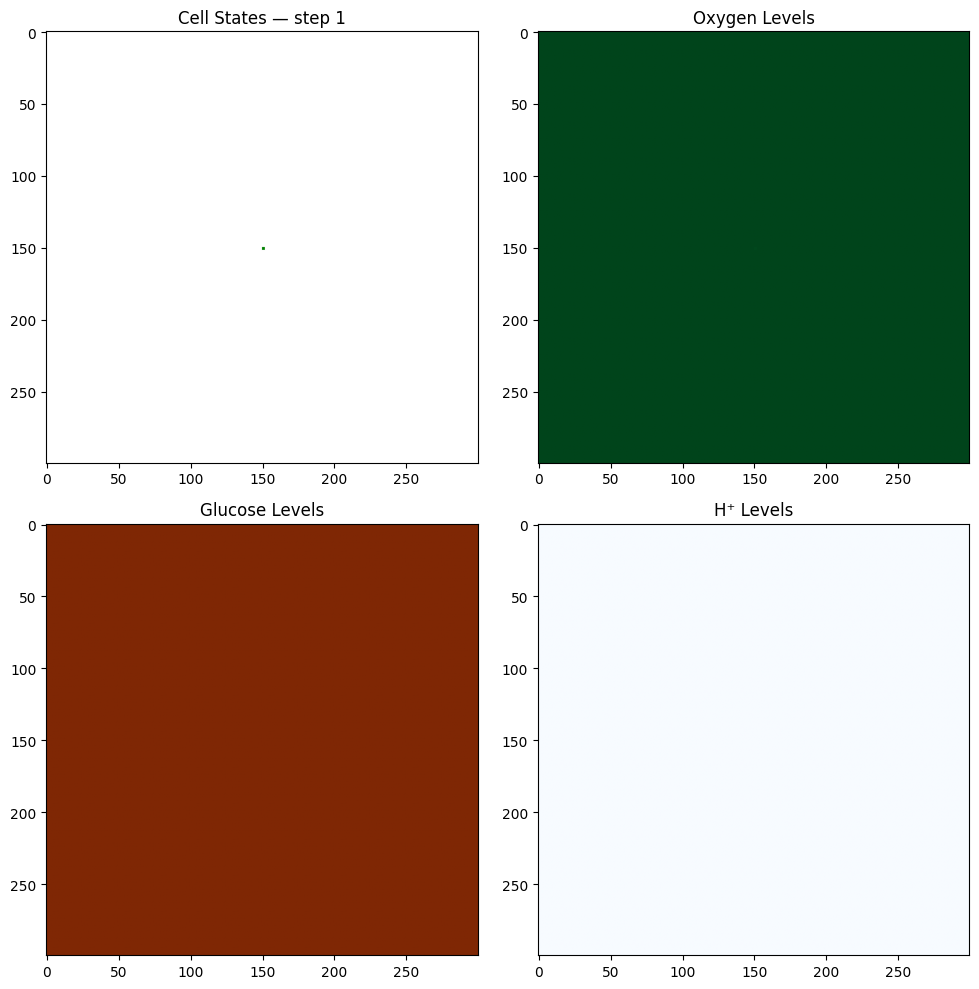

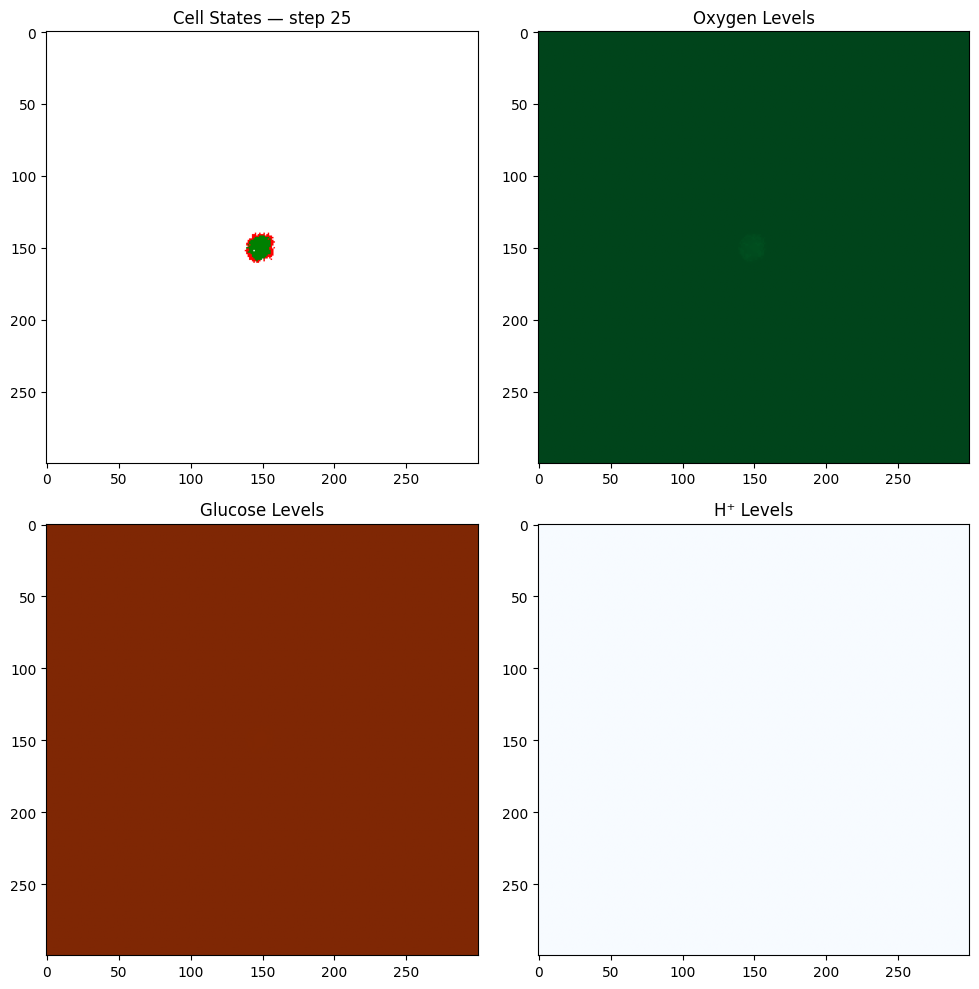

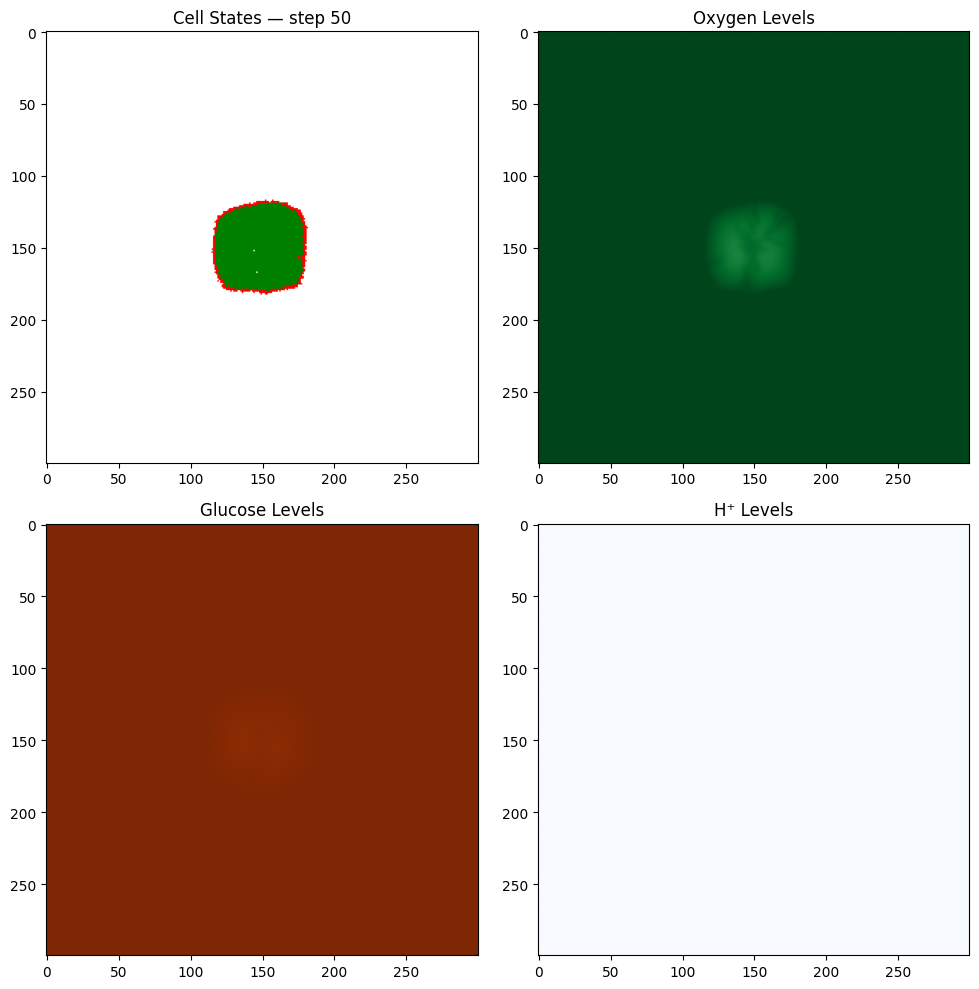

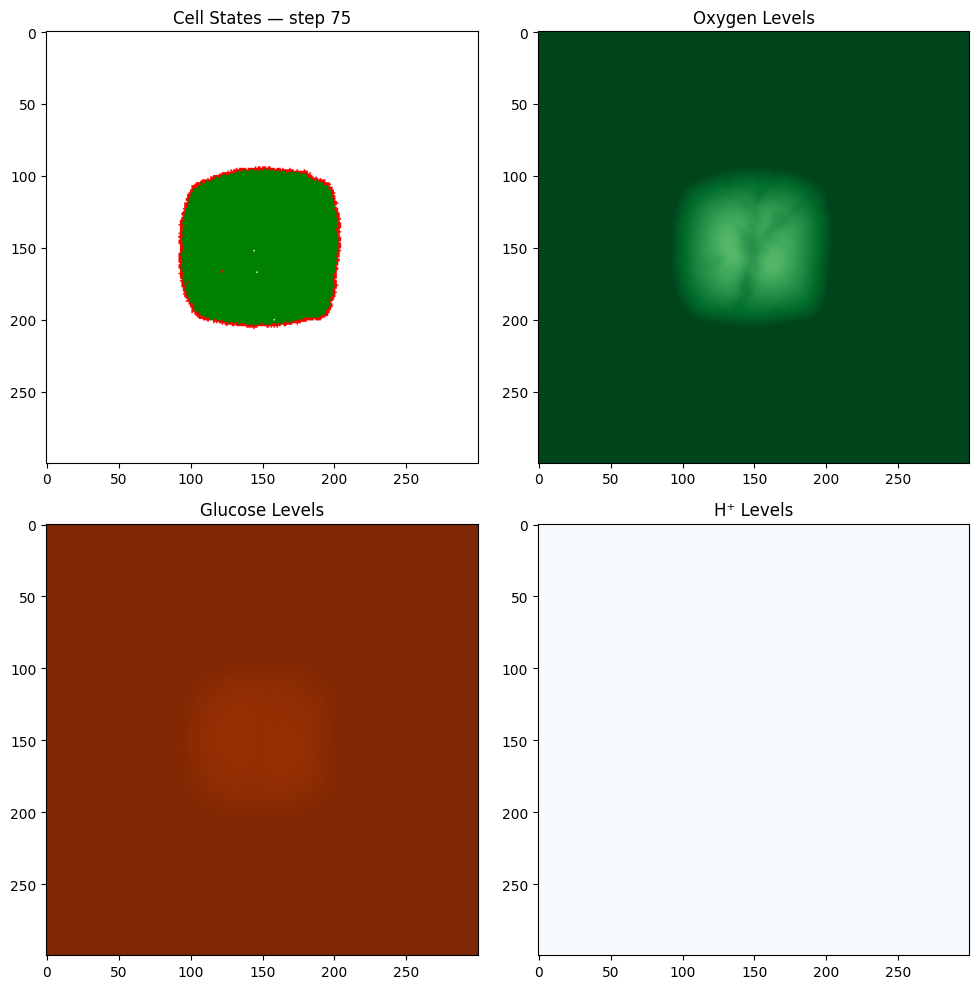

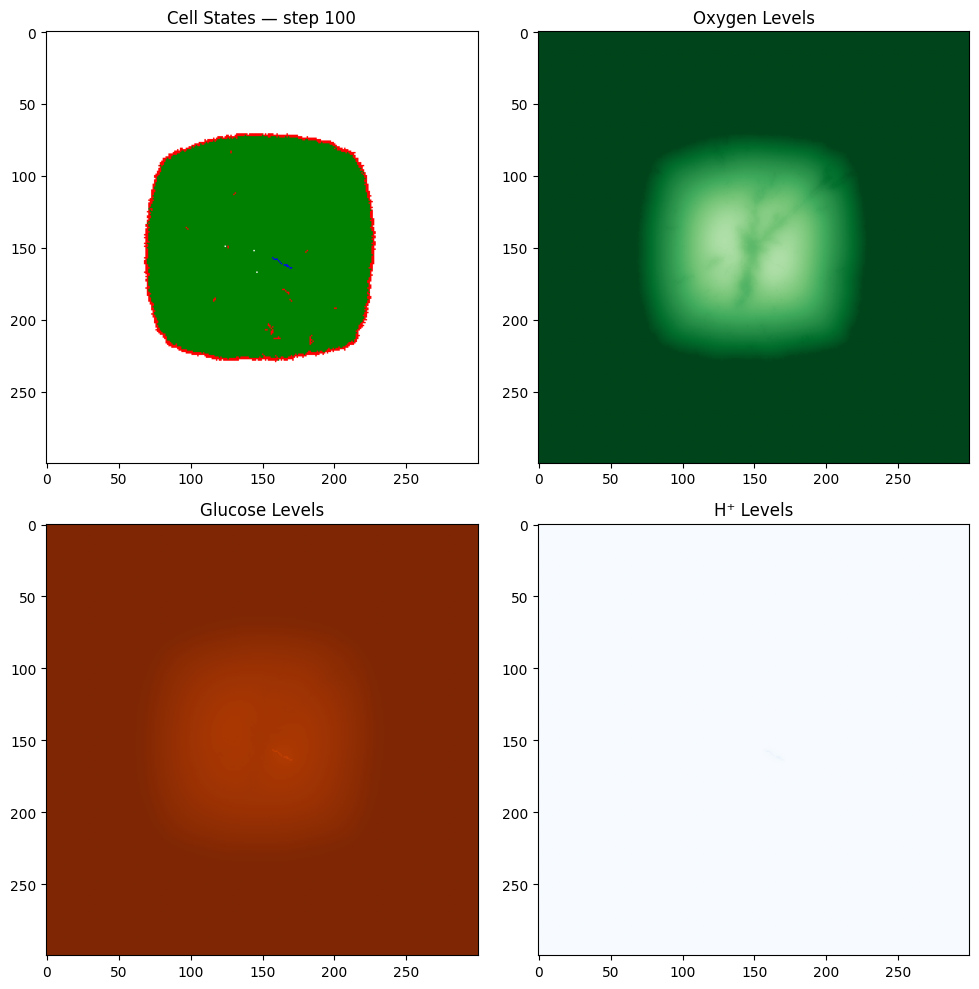

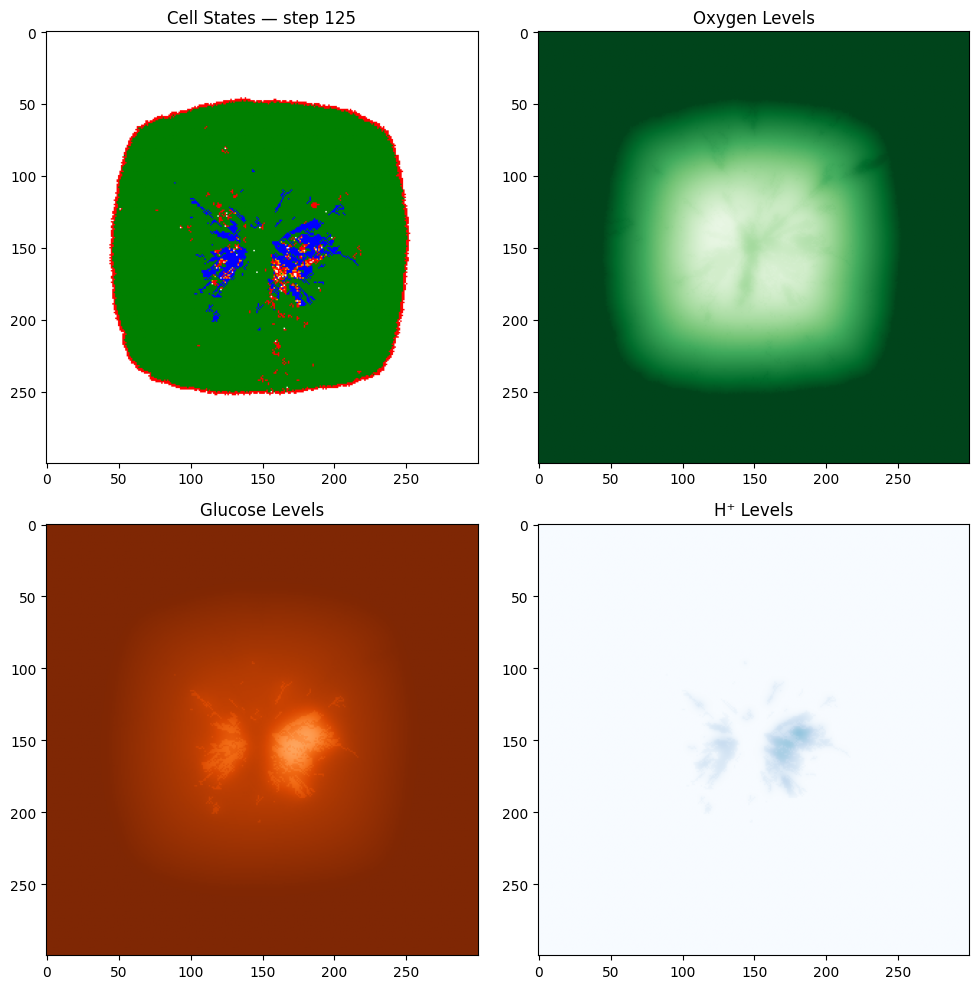

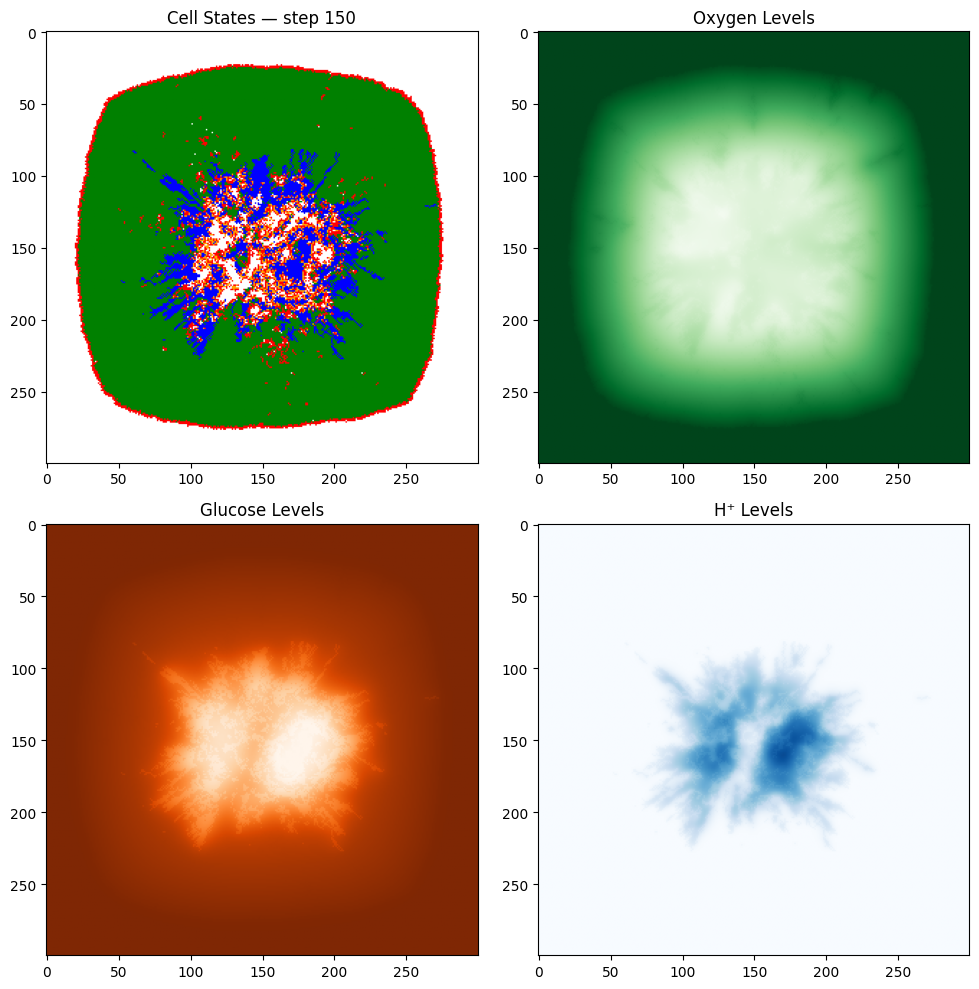

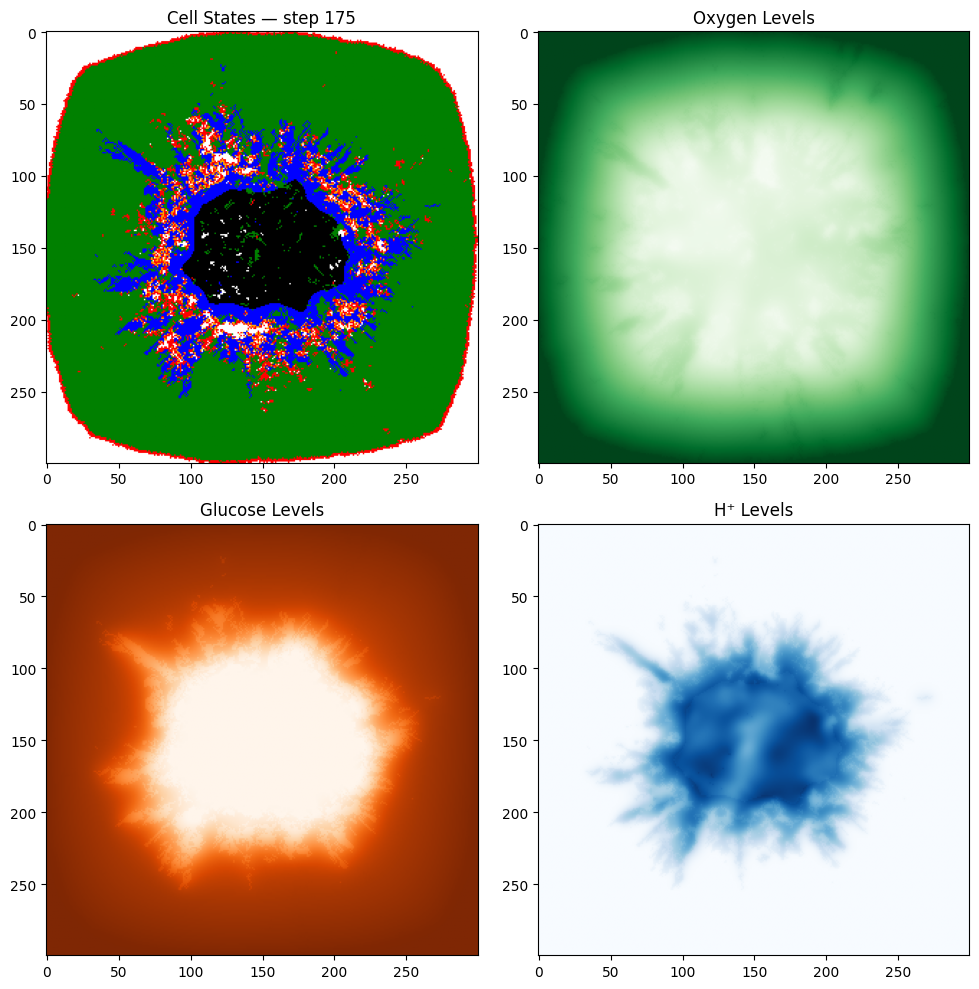

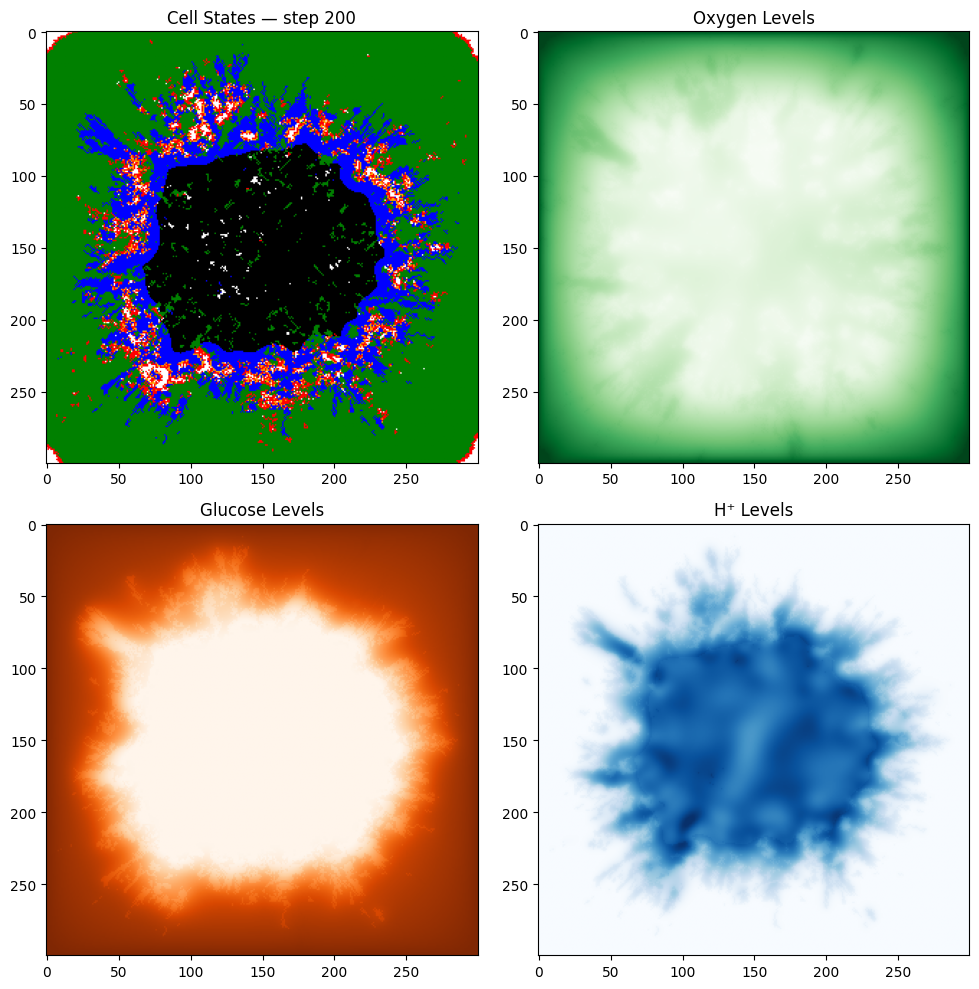

In [24]:
# ── Run Warburg model ───────────────────────────────────────
model_warburg = TestModelWarburg(width=300, height=300)

for i in range(200):
    print(f"Step {i+1}/200", end="\r")
    model_warburg.step()
    

plt.ioff()
plt.show()


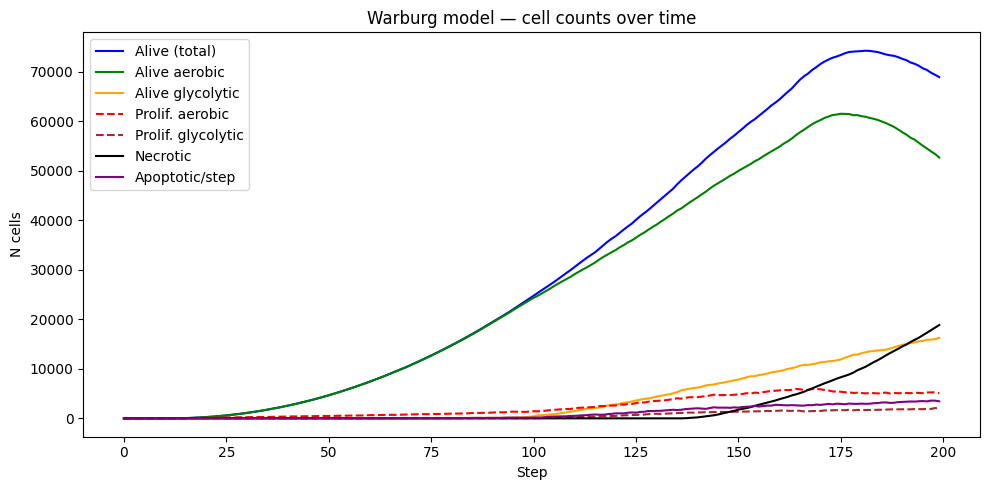

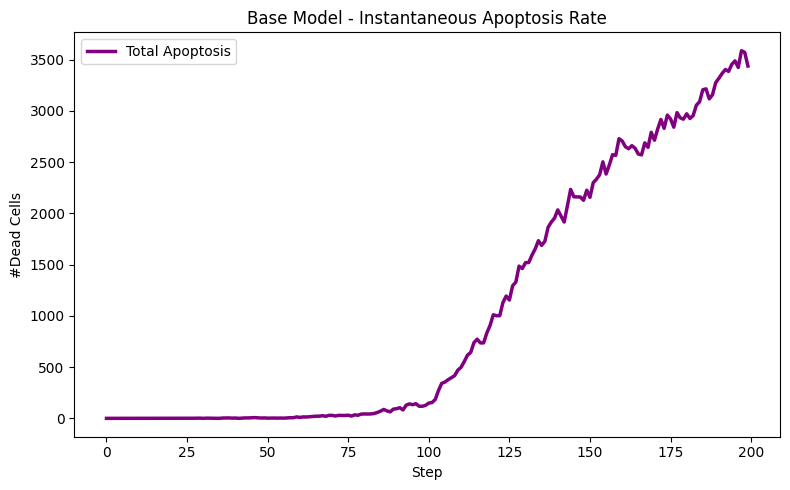

In [11]:
# ── Plot cell counts ─────────────────────────────────────────
df_warb = pd.DataFrame(model_warburg.history)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_warb['alive'],         label='Alive (total)',          color='blue')
ax.plot(df_warb['alive_aero'],    label='Alive aerobic',          color='green')
ax.plot(df_warb['alive_glyco'],   label='Alive glycolytic',       color='orange')
ax.plot(df_warb['prolif_aero'],   label='Prolif. aerobic',        color='red',   linestyle='--')
ax.plot(df_warb['prolif_glyco'],  label='Prolif. glycolytic',     color='brown', linestyle='--')
ax.plot(df_warb['necrotic'],      label='Necrotic',               color='black')
ax.plot(df_warb['apoptotic'],     label='Apoptotic/step',         color='purple')
ax.set_title("Warburg model — cell counts over time")
ax.set_xlabel("Step")
ax.set_ylabel("N cells")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_warb['apoptotic'], color='purple', label='Total Apoptosis', linewidth=2.5)
ax.set_title("Base Model - Instantaneous Apoptosis Rate")
ax.set_xlabel("Step")
ax.set_ylabel("#Dead Cells")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Comparison — Base vs Warburg

The two models are compared on total alive cells, necrotic fraction, and glycolytic emergence. Both simulations use a 300×300 grid with identical initial conditions and stopping criteria.


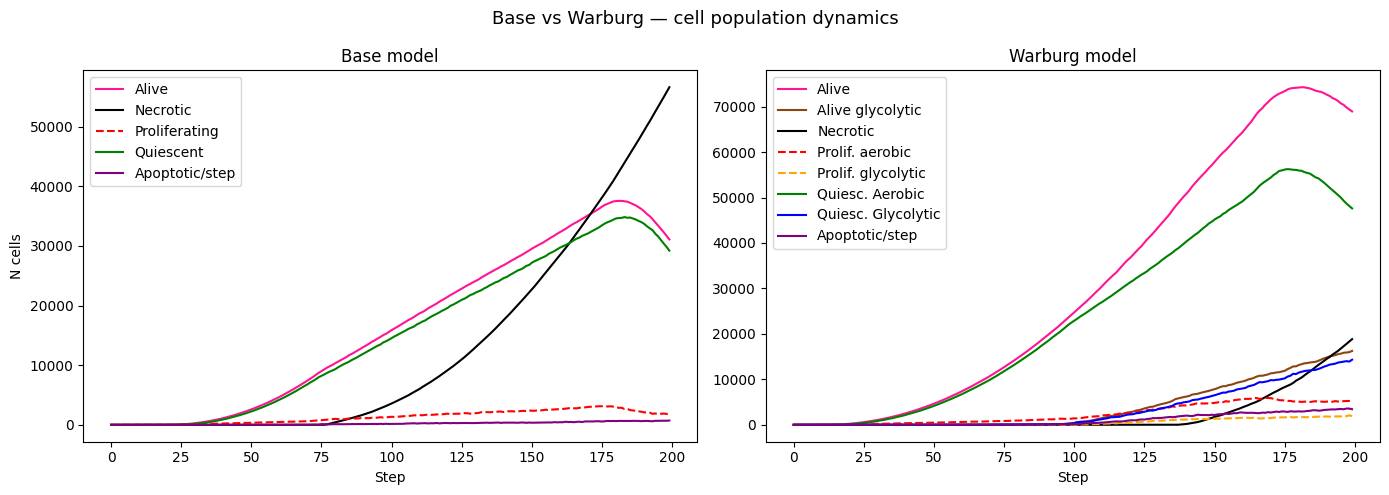

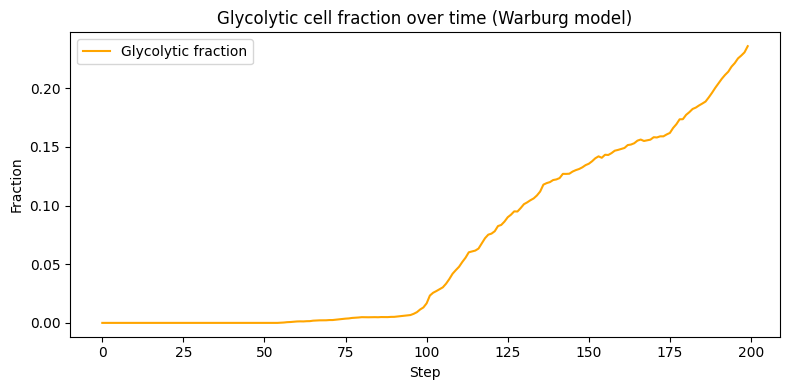

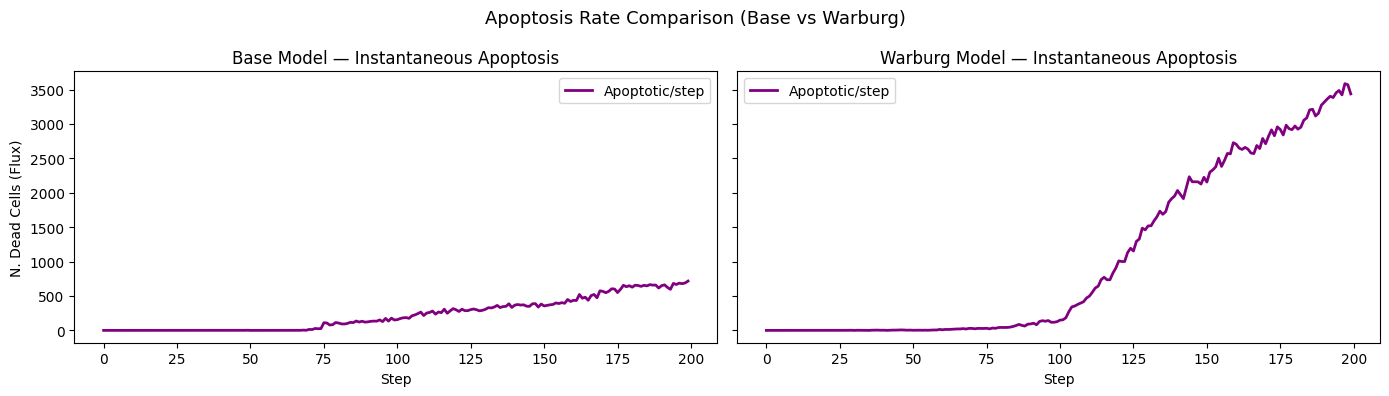

In [25]:
# ── Side-by-side comparison ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base
ax = axes[0]
ax.plot(df_base['alive'],         label='Alive',        color='deeppink')
ax.plot(df_base['necrotic'],      label='Necrotic',     color='black')
ax.plot(df_base['proliferating'], label='Proliferating',color='red',   linestyle='--')
ax.plot(df_base['quiescent'],     label='Quiescent',    color='green')
ax.plot(df_base['apoptotic'],     label='Apoptotic/step',color='purple')
ax.set_title("Base model")
ax.set_xlabel("Step"); ax.set_ylabel("N cells"); ax.legend()

# Warburg
ax = axes[1]
ax.plot(df_warb['alive'],        label='Alive',    color='deeppink')
ax.plot(df_warb['alive_glyco'],  label='Alive glycolytic', color='saddlebrown')
ax.plot(df_warb['necrotic'],     label='Necrotic',         color='black')
ax.plot(df_warb['prolif_aero'],  label='Prolif. aerobic',  color='red',   linestyle='--')
ax.plot(df_warb['prolif_glyco'], label='Prolif. glycolytic',color='orange',linestyle='--')
ax.plot(df_warb['quiesc_aero'],   label='Quiesc. Aerobic',    color='green')
ax.plot(df_warb['quiesc_glyco'],  label='Quiesc. Glycolytic', color='blue')
ax.plot(df_warb['apoptotic'],    label='Apoptotic/step',   color='purple')
ax.set_title("Warburg model")
ax.set_xlabel("Step"); ax.legend()

plt.suptitle("Base vs Warburg — cell population dynamics", fontsize=13)
plt.tight_layout()
plt.show()

# ── Glycolytic fraction over time (Warburg only) ─────────────
fig, ax = plt.subplots(figsize=(8, 4))
glyco_frac = df_warb['alive_glyco'] / df_warb['alive'].replace(0, np.nan)
ax.plot(glyco_frac, color='orange', label='Glycolytic fraction')
ax.set_title("Glycolytic cell fraction over time (Warburg model)")
ax.set_xlabel("Step"); ax.set_ylabel("Fraction"); ax.legend()
plt.tight_layout()
plt.show()

# ── Instantaneous Apoptosis Comparison ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# Base Apoptosis
axes[0].plot(df_base['apoptotic'], color='purple', label='Apoptotic/step', linewidth=2)
axes[0].set_title("Base Model — Instantaneous Apoptosis")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("N. Dead Cells (Flux)")
axes[0].legend()

# Warburg Apoptosis
axes[1].plot(df_warb['apoptotic'], color='purple', label='Apoptotic/step', linewidth=2)
axes[1].set_title("Warburg Model — Instantaneous Apoptosis")
axes[1].set_xlabel("Step")
axes[1].legend()

plt.suptitle("Apoptosis Rate Comparison (Base vs Warburg)", fontsize=13)
plt.tight_layout()
plt.show()
